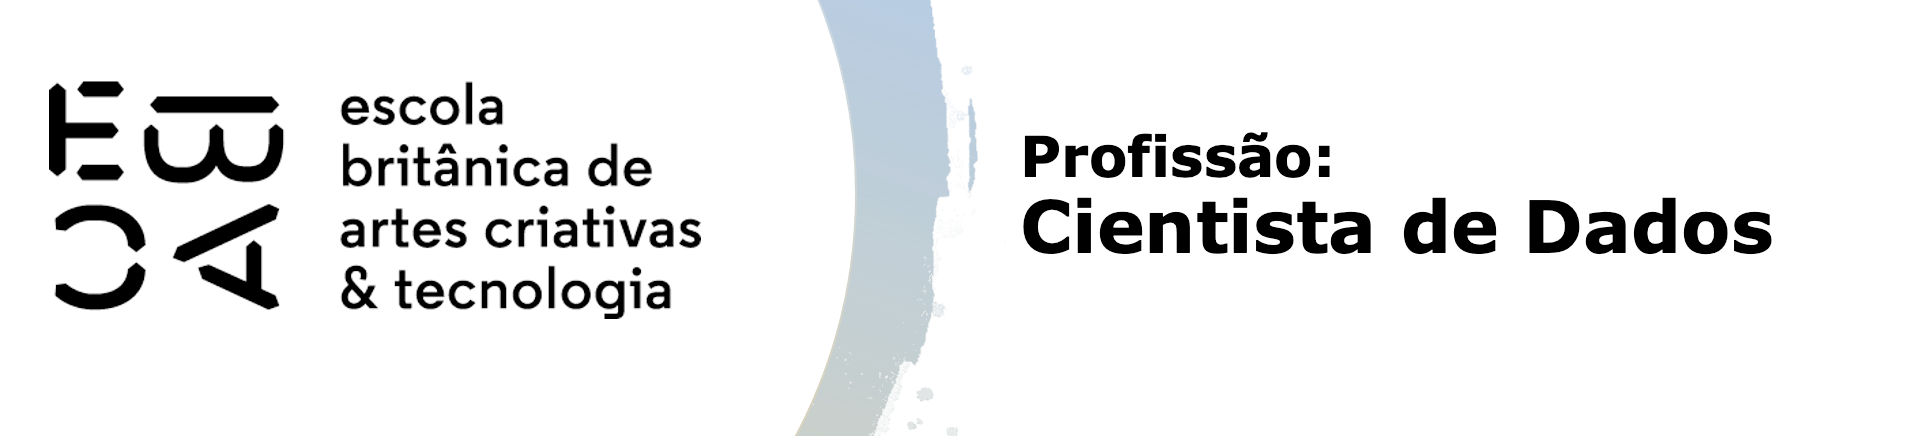

# Tarefa - Agrupamento hierárquico

Neste exercício vamos usar a base [online shoppers purchase intention](https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset) de Sakar, C.O., Polat, S.O., Katircioglu, M. et al. Neural Comput & Applic (2018). [Web Link](https://doi.org/10.1007/s00521-018-3523-0).

A base trata de registros de 12.330 sessões de acesso a páginas, cada sessão sendo de um único usuário em um período de 12 meses, para posteriormente estudarmos a relação entre o design da página e o perfil do cliente - "Será que clientes com comportamento de navegação diferentes possuem propensão a compra diferente?" 

Nosso objetivo agora é agrupar as sessões de acesso ao portal considerando o comportamento de acesso e informações da data, como a proximidade a uma data especial, fim de semana e o mês.

|Variavel                |Descrição          | 
|------------------------|:-------------------| 
|Administrative          | Quantidade de acessos em páginas administrativas| 
|Administrative_Duration | Tempo de acesso em páginas administrativas | 
|Informational           | Quantidade de acessos em páginas informativas  | 
|Informational_Duration  | Tempo de acesso em páginas informativas  | 
|ProductRelated          | Quantidade de acessos em páginas de produtos | 
|ProductRelated_Duration | Tempo de acesso em páginas de produtos | 
|BounceRates             | *Percentual de visitantes que entram no site e saem sem acionar outros *requests* durante a sessão  | 
|ExitRates               | * Soma de vezes que a página é visualizada por último em uma sessão dividido pelo total de visualizações | 
|PageValues              | * Representa o valor médio de uma página da Web que um usuário visitou antes de concluir uma transação de comércio eletrônico | 
|SpecialDay              | Indica a proximidade a uma data festiva (dia das mães etc) | 
|Month                   | Mês  | 
|OperatingSystems        | Sistema operacional do visitante | 
|Browser                 | Browser do visitante | 
|Region                  | Região | 
|TrafficType             | Tipo de tráfego                  | 
|VisitorType             | Tipo de visitante: novo ou recorrente | 
|Weekend                 | Indica final de semana | 
|Revenue                 | Indica se houve compra ou não |

\* variávels calculadas pelo google analytics

In [6]:
#!pip install gower

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from gower import gower_matrix
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [8]:
df = pd.read_csv('online_shoppers_intention.csv')

In [9]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [10]:
df.Revenue.value_counts(dropna=False)

Revenue
False    10422
True      1908
Name: count, dtype: int64

## Análise descritiva

Faça uma análise descritiva das variáveis do escopo.

- Verifique a distribuição dessas variáveis
- Veja se há valores *missing* e caso haja, decida o que fazer
- Faça mais algum tratamento nas variáveis caso ache pertinente

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [13]:
df.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

## Variáveis de agrupamento

Liste as variáveis que você vai querer utilizar. Essa é uma atividade importante do projeto, e tipicamente não a recebemos pronta. Não há resposta pronta ou correta, mas apenas critérios e a sua decisão. Os critérios são os seguintes:

- Selecione para o agrupamento variáveis que descrevam o padrão de navegação na sessão.
- Selecione variáveis que indiquem a característica da data.
- Não se esqueça de que você vai precisar realizar um tratamento especial para variáveis qualitativas.
- Trate adequadamente valores faltantes.

In [15]:
df1 = df[['Revenue', 'BounceRates', 'Administrative_Duration', 'Informational_Duration', 
                  'ProductRelated_Duration', 'PageValues', 'SpecialDay', 'Weekend', 
                   'Month', 'VisitorType']]

df1.head()

,Revenue,BounceRates,Administrative_Duration,Informational_Duration,ProductRelated_Duration,PageValues,SpecialDay,Weekend,Month,VisitorType
0,False,0.20,0.0,0.0,0.000000,0.0,0.0,False,Feb,Returning_Visitor
1,False,0.00,0.0,0.0,64.000000,0.0,0.0,False,Feb,Returning_Visitor
2,False,0.20,0.0,0.0,0.000000,0.0,0.0,False,Feb,Returning_Visitor
3,False,0.05,0.0,0.0,2.666667,0.0,0.0,False,Feb,Returning_Visitor
4,False,0.02,0.0,0.0,627.500000,0.0,0.0,True,Feb,Returning_Visitor


In [16]:
variaveis = df1.columns.values[2:]
variaveis

array(['Administrative_Duration', 'Informational_Duration',
       'ProductRelated_Duration', 'PageValues', 'SpecialDay', 'Weekend',
       'Month', 'VisitorType'], dtype=object)

In [17]:
variaveis_cat = variaveis[-2:]
variaveis_cat

array(['Month', 'VisitorType'], dtype=object)

In [18]:
df2 = pd.get_dummies(df1[variaveis].dropna())
df2.head()

,Administrative_Duration,Informational_Duration,ProductRelated_Duration,PageValues,SpecialDay,Weekend,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0.0,0.0,0.000000,0.0,0.0,False,False,False,True,False,False,False,False,False,False,False,False,False,True
1,0.0,0.0,64.000000,0.0,0.0,False,False,False,True,False,False,False,False,False,False,False,False,False,True
2,0.0,0.0,0.000000,0.0,0.0,False,False,False,True,False,False,False,False,False,False,False,False,False,True
3,0.0,0.0,2.666667,0.0,0.0,False,False,False,True,False,False,False,False,False,False,False,False,False,True
4,0.0,0.0,627.500000,0.0,0.0,True,False,False,True,False,False,False,False,False,False,False,False,False,True


In [19]:
df2.columns.values

array(['Administrative_Duration', 'Informational_Duration',
       'ProductRelated_Duration', 'PageValues', 'SpecialDay', 'Weekend',
       'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June',
       'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep',
       'VisitorType_New_Visitor', 'VisitorType_Other',
       'VisitorType_Returning_Visitor'], dtype=object)

In [20]:
vars_cat = [True if x in {'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June',
       'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 
       'VisitorType_New_Visitor', 'VisitorType_Other', 
       'VisitorType_Returning_Visitor'} else False for x in df2.columns]

In [21]:
cols_to_standardize = ['Administrative_Duration', 'Informational_Duration', 
                       'ProductRelated_Duration', 'PageValues']

scaler = StandardScaler()
df2[cols_to_standardize] = scaler.fit_transform(df2[cols_to_standardize])

In [22]:
df2.shape

(12330, 19)

## Número de grupos

Nesta atividade vamos adotar uma abordagem bem pragmática e avaliar agrupamentos hierárquicos com 3 e 4 grupos, por estarem bem alinhados com uma expectativa e estratégia do diretor da empresa. 

*Atenção*: Cuidado se quiser fazer o dendrograma, pois com muitas observações ele pode ser mais complicado de fazer, e dependendo de como for o comando, ele pode travar o *kernell* do seu python.

In [24]:
distancia_gower = gower_matrix(df2, cat_features=vars_cat)

In [25]:
gdv = squareform(distancia_gower,force='tovector')

In [26]:
gdv.shape

(76008285,)

In [27]:
Z = linkage(gdv, method='complete')
Z_df = pd.DataFrame(Z,columns=['id1','id2','dist','n'])
Z_df.head()

,id1,id2,dist,n
0,0.0,2.0,0.0,2.0
1,16.0,12330.0,0.0,3.0
2,21.0,12331.0,0.0,4.0
3,64.0,12332.0,0.0,5.0
4,70.0,12333.0,0.0,6.0


Leaves = 10674


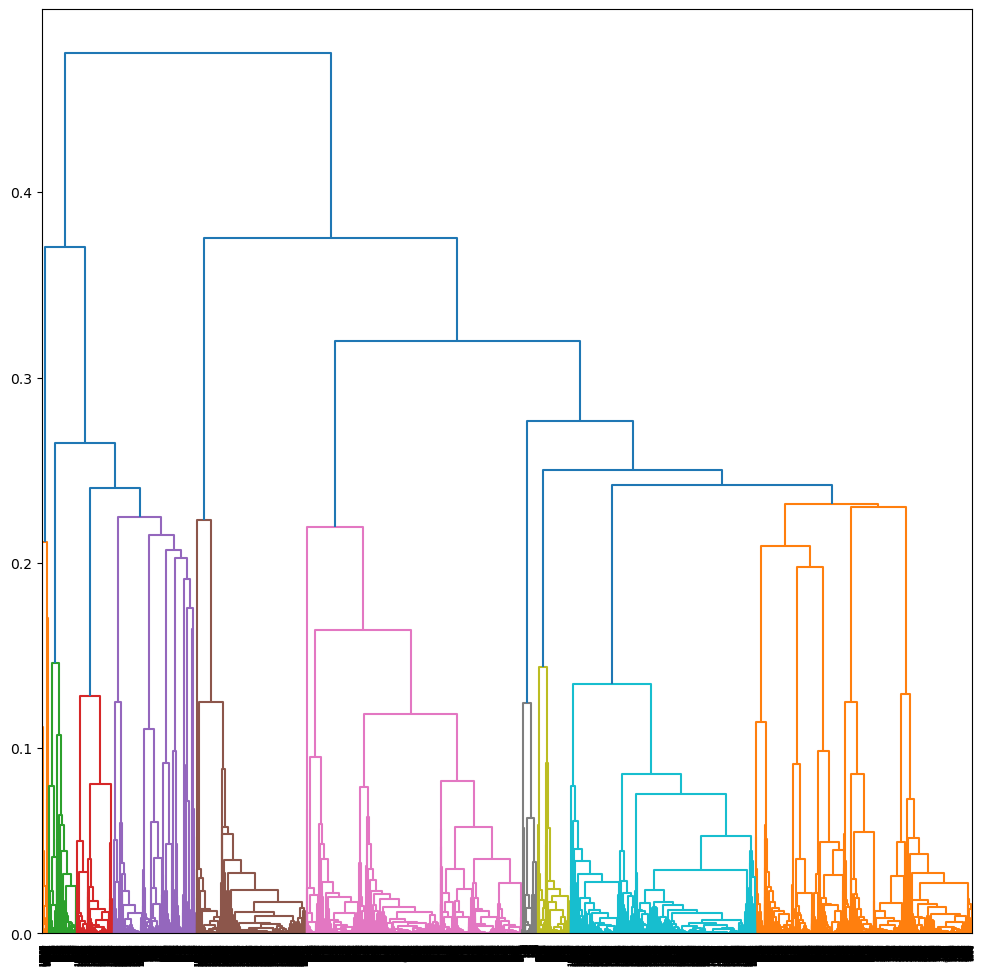

In [28]:
fig,axs = plt.subplots(1,1,figsize=(12,12))
dn = dendrogram(Z, truncate_mode='level',p=30,show_leaf_counts=True,ax=axs, color_threshold=.24)
print(f"Leaves = {len(dn['leaves'])}")

## Avaliação dos grupos

Construa os agrupamentos com a técnica adequada que vimos em aula. Não se esqueça de tratar variáveis qualitativas, padronizar escalas das quantitativas, tratar valores faltantes e utilizar a distância correta.

Faça uma análise descritiva para pelo menos duas soluções de agrupamentos (duas quantidades diferentes de grupos) sugeridas no item anterior, utilizando as variáveis que estão no escopo do agrupamento.
- Com base nesta análise e nas análises anteriores, decida pelo agrupamento final. 
- Se puder, sugira nomes para os grupos.

In [30]:
df2 ['3_grupos'] = fcluster(Z, t=3, criterion='maxclust')

df2 ['4_grupos'] = fcluster(Z, t=4, criterion='maxclust')

In [31]:
columns_to_add = df1[['BounceRates', 'Revenue']]


df3 = df2.join(columns_to_add)


df3.head()

,Administrative_Duration,Informational_Duration,ProductRelated_Duration,PageValues,SpecialDay,Weekend,Month_Aug,Month_Dec,Month_Feb,Month_Jul,...,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor,3_grupos,4_grupos,BounceRates,Revenue
0,-0.457191,-0.244931,-0.624348,-0.317178,0.0,False,False,False,True,False,...,False,False,False,False,False,True,3,4,0.20,False
1,-0.457191,-0.244931,-0.590903,-0.317178,0.0,False,False,False,True,False,...,False,False,False,False,False,True,3,4,0.00,False
2,-0.457191,-0.244931,-0.624348,-0.317178,0.0,False,False,False,True,False,...,False,False,False,False,False,True,3,4,0.20,False
3,-0.457191,-0.244931,-0.622954,-0.317178,0.0,False,False,False,True,False,...,False,False,False,False,False,True,3,4,0.05,False
4,-0.457191,-0.244931,-0.296430,-0.317178,0.0,True,False,False,True,False,...,False,False,False,False,False,True,3,4,0.02,False


In [32]:
result = df3.groupby(['Revenue', '3_grupos'])['BounceRates'].mean().unstack().fillna(0)

result.style.format("{:.2f}")

3_grupos,1,2,3
Revenue,,,
False,0.01,0.03,0.03
True,0.00,0.00,0.01


Os grupos 2 e 3 apresentam a maior taxa de rejeição entre os usuários que não realizam conversão, o que pode indicar baixo engajamento. Isso sugere a necessidade de estratégias específicas para aumentar o interesse e a interação desses usuários, aproximando-os do comportamento observado no grupo 1, que apresenta melhor desempenho.

Já entre os usuários que convertem, todos os grupos registram taxas de rejeição extremamente baixas (0 ou 0,01), o que indica que esses usuários costumam explorar o site de forma mais consistente antes de efetuar uma compra.

In [34]:
result = df3.groupby(['Revenue', '4_grupos'])['BounceRates'].mean().unstack().fillna(0)

result.style.format("{:.2f}")

4_grupos,1,2,3,4
Revenue,,,,
False,0.05,0.01,0.03,0.03
True,0.00,0.00,0.00,0.01


O Grupo 2 se destaca como o mais engajado entre os usuários que não converteram, registrando a menor taxa de rejeição. Esse comportamento indica maior propensão à navegação e potencial de conversão futura.

Por outro lado, o Grupo 1 apresenta a maior taxa de rejeição nesse mesmo segmento, seguido pelos grupos 3 e 4. Esses dados sugerem a necessidade de estratégias específicas para melhorar o engajamento desses usuários e reduzir a evasão precoce.

No caso dos usuários que convertem, todos os grupos mantêm taxas de rejeição praticamente nulas, o que reforça o padrão observado: usuários que finalizam uma conversão tendem a interagir mais com o site antes de realizar a compra.

Quando olhamos para os usuários que não compram (Revenue = False), os dois agrupamentos têm a mesma menor taxa de rejeição: 1%. Porém, a maior taxa muda: com 4 grupos, ela chega a 5% no grupo 4, enquanto com 3 grupos, a maior taxa é 3%. Isso mostra que, com 4 grupos, conseguimos ver melhor qual grupo tem o pior desempenho, mas também mostra mais variação entre eles.

Para os usuários que compram (Revenue = True), as duas tabelas são parecidas: a maior taxa de rejeição é de apenas 1% em um dos grupos, e os outros grupos têm taxa zero. Isso confirma que quem compra costuma navegar mais antes de sair do site.

A vantagem dos 4 grupos é que conseguimos identificar melhor o grupo com 5% de rejeição, mas como também é importante melhorar os grupos com 3% de rejeição, usar 3 grupos pode ser mais simples e já ajuda nas decisões.

## Avaliação de resultados

Avalie os grupos obtidos com relação às variáveis fora do escopo da análise (minimamente *bounce rate* e *revenue*). 
- Qual grupo possui clientes mais propensos à compra?

In [38]:
X = df3.dropna()[[ 'Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
                   'PageValues', 'SpecialDay', 'Weekend', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 
                   'Month_June','Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 
                   'VisitorType_New_Visitor', 'VisitorType_Other', 'VisitorType_Returning_Visitor']]

y = df3.dropna()['3_grupos']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=2360873)

In [40]:
clf = RandomForestClassifier(random_state=2360873, n_estimators=50)

grid_parametros = {'ccp_alpha':np.arange(0, .1, .01)}

In [41]:
grid = GridSearchCV(estimator = clf, param_grid=grid_parametros, cv=4, verbose=100)
grid.fit(X_train, y_train) 

Fitting 4 folds for each of 10 candidates, totalling 40 fits
[CV 1/4; 1/10] START ccp_alpha=0.0..............................................
[CV 1/4; 1/10] END ...............ccp_alpha=0.0;, score=1.000 total time=   0.1s
[CV 2/4; 1/10] START ccp_alpha=0.0..............................................
[CV 2/4; 1/10] END ...............ccp_alpha=0.0;, score=1.000 total time=   0.1s
[CV 3/4; 1/10] START ccp_alpha=0.0..............................................
[CV 3/4; 1/10] END ...............ccp_alpha=0.0;, score=1.000 total time=   0.1s
[CV 4/4; 1/10] START ccp_alpha=0.0..............................................
[CV 4/4; 1/10] END ...............ccp_alpha=0.0;, score=1.000 total time=   0.0s
[CV 1/4; 2/10] START ccp_alpha=0.01.............................................
[CV 1/4; 2/10] END ..............ccp_alpha=0.01;, score=1.000 total time=   0.1s
[CV 2/4; 2/10] START ccp_alpha=0.01.............................................
[CV 2/4; 2/10] END ..............ccp_alpha=0.01;

GridSearchCV(cv=4,
             estimator=RandomForestClassifier(n_estimators=50,
                                              random_state=2360873),
             param_grid={'ccp_alpha': array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09])},
             verbose=100)

In [42]:
resultados = pd.DataFrame(grid.cv_results_)
resultados

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
0,0.152009,0.012739,0.010620,0.008062,0.00,{'ccp_alpha': 0.0},1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1
1,0.156092,0.009277,0.006123,0.006126,0.01,{'ccp_alpha': 0.01},1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1
2,0.166986,0.019574,0.006941,0.003174,0.02,{'ccp_alpha': 0.02},1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1
3,0.159862,0.016843,0.005108,0.002926,0.03,{'ccp_alpha': 0.03},1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1
4,0.160633,0.021767,0.005973,0.005156,0.04,{'ccp_alpha': 0.04},1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1
5,0.160064,0.020584,0.004401,0.005555,0.05,{'ccp_alpha': 0.05},1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1
6,0.175013,0.018928,0.003739,0.003873,0.06,{'ccp_alpha': 0.06},1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1
7,0.159154,0.023428,0.002899,0.002082,0.07,{'ccp_alpha': 0.07},1.000000,0.996756,0.997161,0.993106,0.996756,0.002450,8
8,0.149274,0.009872,0.001797,0.003113,0.08,{'ccp_alpha': 0.08},0.996756,0.996756,0.997161,0.993106,0.995945,0.001647,9
9,0.190743,0.010405,0.003923,0.002935,0.09,{'ccp_alpha': 0.09},0.892944,0.892133,0.892133,0.892539,0.892437,0.000336,10


In [43]:
grid.best_params_

{'ccp_alpha': 0.0}

In [44]:
clf = RandomForestClassifier(random_state=2360873, n_estimators=50, ccp_alpha=0.01)
clf.fit(X_train,y_train)

RandomForestClassifier(ccp_alpha=0.01, n_estimators=50, random_state=2360873)

In [45]:
clf.score(X_test, y_test)

1.0

Neste exercício, optamos por utilizar o agrupamento em 3 clusters como base para o modelo de classificação, considerando a boa separação dos grupos e a simplicidade na interpretação dos resultados.

O modelo de regressão treinado com essa segmentação obteve um desempenho excelente, alcançando 100% de acurácia no conjunto de teste. Embora esse valor seja extremamente alto e pouco comum em problemas reais, ele indica que os dados utilizados apresentam padrões bem definidos, o que favoreceu o aprendizado do modelo.

A análise final aponta uma conclusão importante: usuários com maior engajamento tendem a apresentar maior propensão à conversão. Essa relação direta reforça o potencial do uso de clustering como uma etapa estratégica na modelagem preditiva e no direcionamento de ações voltadas à conversão.